In [1]:
!git clone https://github.com/mala-lab/APT.git

Cloning into 'APT'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 107 (delta 13), reused 99 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 1.40 MiB | 10.57 MiB/s, done.
Resolving deltas: 100% (13/13), done.


In [2]:
!pip install pyspark

In [3]:
# 1. Vào thư mục làm việc chính của Kaggle
%cd /kaggle/working

# 2. Clone Dassl.pytorch
!git clone https://github.com/KaiyangZhou/Dassl.pytorch.git

# 3. Vào thư mục Dassl và cài đặt thư viện phụ thuộc
%cd /kaggle/working/Dassl.pytorch
!pip install -r requirements.txt

# 4. Cài đặt Dassl vào môi trường
!python setup.py develop

# 5. Quay trở lại thư mục gốc để chuẩn bị cho các bước sau
%cd /kaggle/working

/kaggle/working
Cloning into 'Dassl.pytorch'...
remote: Enumerating objects: 2477, done.
remote: Counting objects: 100% (1081/1081), done.
remote: Compressing objects: 100% (235/235), done.
remote: Total 2477 (delta 933), reused 846 (delta 846), pack-reused 1396 (from 1)
Receiving objects: 100% (2477/2477), 410.19 KiB | 4.94 MiB/s, done.
Resolving deltas: 100% (1676/1676), done.
/kaggle/working/Dassl.pytorch
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.9/69.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.3/185.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.5/92.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 74.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
# 1. Quay về thư mục làm việc chính của Kaggle (Thay vì /content)
%cd /kaggle/working

# 2. Cài đặt CLIP từ source của OpenAI
# LƯU Ý: Bạn cần bật "Internet" trong phần Settings của Notebook bên thanh phải
!pip install git+https://github.com/openai/CLIP.git

# 3. Cài đặt các thư viện phụ thuộc
# (Kaggle đã có sẵn pandas, sklearn... nhưng chạy lại để đảm bảo đủ thư viện thiếu như yacs, ftfy)
!pip install yacs gdown future scipy scikit-learn tqdm ftfy regex matplotlib pandas

# 4. (Tùy chọn) Cài đặt gdown
!pip install gdown

/kaggle/working
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-4lloybnf
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-4lloybnf
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=72178acbeeacd192ebaed147f567c7c3196beb6e3377ae7aeea6e36b23de640b
  Stored in directory: /tmp/pip-ephem-wheel-cache-ldglqr2i/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [5]:
import sys
import os

# --- FIX LỖI IMPORT TRÊN KAGGLE ---
# Thêm đường dẫn chứa code Dassl vào danh sách tìm kiếm của Python
if "/kaggle/working/Dassl.pytorch" not in sys.path:
    sys.path.append("/kaggle/working/Dassl.pytorch")
# ----------------------------------

%cd /kaggle/working
import dassl
import clip
import torch

print(f"Dassl version: {dassl.__version__}")
print(f"PyTorch version: {torch.__version__}")
print("Cài đặt thành công!")

/kaggle/working
Dassl version: 0.6.3
PyTorch version: 2.8.0+cu126
Cài đặt thành công!


In [6]:
import os

# Đường dẫn file lỗi trong thư viện Dassl trên Kaggle
# Lưu ý: Khi pip install ., code thường nằm trong site-packages hoặc folder src
# Nhưng vì bạn clone về /kaggle/working/Dassl.pytorch, ta sửa trực tiếp ở đó
file_path = '/kaggle/working/Dassl.pytorch/dassl/optim/lr_scheduler.py'

print(f"🔧 Đang sửa file: {file_path}")

if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    new_lines = []
    fixed = False
    
    for line in lines:
        # Tìm dòng lỗi và xóa tham số verbose
        if 'super().__init__(optimizer, last_epoch, verbose)' in line:
            new_line = line.replace(', verbose)', ')')
            new_lines.append(new_line)
            fixed = True
        else:
            new_lines.append(line)
            
    if fixed:
        with open(file_path, 'w') as f:
            f.writelines(new_lines)
        print("✅ Đã sửa lỗi Dassl thành công!")
    else:
        print("⚠️ Không tìm thấy dòng lỗi (có thể đã sửa rồi).")
    
    # Cài đặt lại Dassl để áp dụng thay đổi
    print("🔄 Đang cài đặt lại Dassl...")
    %cd /kaggle/working/Dassl.pytorch
    !pip install .
    %cd /kaggle/working
else:
    print("❌ Không tìm thấy file Dassl. Hãy đảm bảo bạn đã clone repo.")

🔧 Đang sửa file: /kaggle/working/Dassl.pytorch/dassl/optim/lr_scheduler.py
✅ Đã sửa lỗi Dassl thành công!
🔄 Đang cài đặt lại Dassl...
/kaggle/working/Dassl.pytorch
Processing /kaggle/working/Dassl.pytorch
  Preparing metadata (setup.py) ... done
  Created wheel for dassl: filename=dassl-0.6.3-py3-none-any.whl size=138529 sha256=d74a8954d3551270b032ae175ff158cee432e22b4d4deccbdb2cc3030dcf8743
  Stored in directory: /tmp/pip-ephem-wheel-cache-ebnbut9w/wheels/0b/38/eb/c9c538e4940264d538630e38d6763aeb5b53dfb3c85e5d6a0e
Successfully built dassl
  Attempting uninstall: dassl
    Found existing installation: dassl 0.6.3
    Uninstalling dassl-0.6.3:
      Successfully uninstalled dassl-0.6.3
/kaggle/working


In [7]:
%%writefile /kaggle/working/APT/train.py
import argparse
import torch
import os

from dassl.utils import setup_logger, set_random_seed, collect_env_info
from dassl.config import get_cfg_default
from dassl.engine import build_trainer
import trainers.locoop
import trainers.sct
import datasets.imagenet

def print_args(args, cfg):
    print("***************")
    print("** Arguments **")
    print("***************")
    optkeys = list(args.__dict__.keys())
    optkeys.sort()
    for key in optkeys:
        print("{}: {}".format(key, args.__dict__[key]))
    print("************")
    print("** Config **")
    print("************")
    print(cfg)

def reset_cfg(cfg, args):
    if args.root: cfg.DATASET.ROOT = args.root
    if args.output_dir: cfg.OUTPUT_DIR = args.output_dir
    if args.resume: cfg.RESUME = args.resume
    if args.seed: cfg.SEED = args.seed
    if args.trainer: cfg.TRAINER.NAME = args.trainer
    if args.backbone: cfg.MODEL.BACKBONE.NAME = args.backbone
    if args.head: cfg.MODEL.HEAD.NAME = args.head
    if args.topk: cfg.topk = args.topk
    cfg.lambda_value = args.lambda_value
    cfg.Outlier_back = args.Outlier_back
    cfg.Outlier_fore = args.Outlier_fore
    cfg.Outlier_back_fore = args.Outlier_back_fore
    cfg.kl = args.kl
    cfg.prob = args.prob
    cfg.baseline = args.baseline
    cfg.lambda_value_back = args.lambda_value_back
    cfg.lambda_value_fore = args.lambda_value_fore
    cfg.limited_fore = args.limited_fore
    cfg.in_dataset = args.in_dataset

def extend_cfg(cfg):
    from yacs.config import CfgNode as CN
    cfg.TRAINER.LOCOOP = CN()
    cfg.TRAINER.LOCOOP.N_CTX = 16
    cfg.TRAINER.LOCOOP.CSC = False
    cfg.TRAINER.LOCOOP.CTX_INIT = ""
    cfg.TRAINER.LOCOOP.PREC = "fp16"
    cfg.TRAINER.LOCOOP.CLASS_TOKEN_POSITION = "end"
    cfg.TRAINER.LOCOOP_v5 = CN()
    cfg.TRAINER.LOCOOP_v5.N_CTX = 16
    cfg.TRAINER.LOCOOP_v5.CSC = False
    cfg.TRAINER.LOCOOP_v5.CTX_INIT = ""
    cfg.TRAINER.LOCOOP_v5.PREC = "fp16"
    cfg.TRAINER.LOCOOP_v5.CLASS_TOKEN_POSITION = "end"
    cfg.DATASET.SUBSAMPLE_CLASSES = "all"

def setup_cfg(args):
    cfg = get_cfg_default()
    extend_cfg(cfg)
    if args.dataset_config_file: cfg.merge_from_file(args.dataset_config_file)
    if args.config_file: cfg.merge_from_file(args.config_file)
    reset_cfg(cfg, args)
    cfg.merge_from_list(args.opts)
    cfg.freeze()
    return cfg

def main(args):
    cfg = setup_cfg(args)
    if cfg.SEED >= 0:
        print("Setting fixed seed: {}".format(cfg.SEED))
        set_random_seed(cfg.SEED)
    setup_logger(cfg.OUTPUT_DIR)
    
    if torch.cuda.is_available() and cfg.USE_CUDA:
        torch.backends.cudnn.benchmark = True
        # --- QUAN TRỌNG: Sửa thành '0' cho Kaggle ---
        os.environ['CUDA_VISIBLE_DEVICES'] = "0"

    print_args(args, cfg)
    print("Collecting env info ...")
    print("** System info **\n{}\n".format(collect_env_info()))
    
    trainer = build_trainer(cfg)
    
    if args.eval_only:
        trainer.load_model(args.model_dir, epoch=args.load_epoch)
        trainer.test()
        return
    if not args.no_train:
        trainer.train()

def str2bool(v):
    if isinstance(v, bool): return v
    if v.lower() in ('true', 'True'): return True
    elif v.lower() in ('false', 'False'): return False
    else: raise argparse.ArgumentTypeError('Boolean value expected.')

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--root", type=str, default="", help="path to dataset")
    parser.add_argument("--output-dir", type=str, default="output/test", help="output directory")
    parser.add_argument("--resume", type=str, default="", help="checkpoint directory")
    parser.add_argument("--seed", type=int, default=1, help="only positive value enables a fixed seed")
    parser.add_argument("--config-file", type=str, default="configs/trainers/LoCoOp/vit_b16_ep25.yaml", help="path to config file")
    parser.add_argument("--dataset-config-file", type=str, default="configs/datasets/imagenet.yaml", help="path to config file")
    parser.add_argument("--trainer", type=str, default="sct", help="name of trainer")
    parser.add_argument("--backbone", type=str, default="", help="name of CNN backbone")
    parser.add_argument("--head", type=str, default="", help="name of head")
    parser.add_argument("--eval-only", action="store_true", help="evaluation only")
    parser.add_argument("--model-dir", type=str, default="", help="load model directory")
    parser.add_argument("--load-epoch", type=int, help="load model weights at this epoch")
    parser.add_argument("--no-train", action="store_true", help="do not call trainer.train()")
    parser.add_argument("opts", default=None, nargs=argparse.REMAINDER, help="modify config options")
    
    # Custom params
    parser.add_argument('--lambda_value', type=float, default=0)
    parser.add_argument('--topk', type=int, default=200)
    parser.add_argument('--Outlier_back', type=str2bool, default=True)
    parser.add_argument('--Outlier_fore', type=str2bool, default=False)
    parser.add_argument('--Outlier_back_fore', type=str2bool, default=True)
    parser.add_argument('--kl', type=float, default=0.35)
    parser.add_argument('--prob', type=str, default="normal")
    parser.add_argument('--limited_fore', type=str2bool, default=False)
    parser.add_argument('--baseline', type=str, default="LoCoOp")
    parser.add_argument('--lambda_value_back', type=float, default=0)
    parser.add_argument('--lambda_value_fore', type=float, default=0)
    parser.add_argument('--in_dataset', type=str, default='imagenet')
    
    args = parser.parse_args()
    main(args)

Overwriting /kaggle/working/APT/train.py


In [8]:
import os
import shutil

# 1. Tải dữ liệu
print("⏳ Đang tải Textures (DTD)...")
# Xóa file cũ nếu có để tránh lỗi
if os.path.exists("dtd-r1.0.1.tar.gz"):
    os.remove("dtd-r1.0.1.tar.gz")
    
!wget -q https://www.robots.ox.ac.uk/~vgg/data/dtd/download/dtd-r1.0.1.tar.gz

# 2. Giải nén
print("📦 Đang giải nén...")
extract_path = "/kaggle/working/APT/data/"

# --- SỬA LỖI TẠI ĐÂY: Tạo thư mục trước ---
os.makedirs(extract_path, exist_ok=True) 
# ------------------------------------------

!tar -xf dtd-r1.0.1.tar.gz -C {extract_path}

# 3. Kiểm tra và Xử lý thư mục
# File nén này thường giải nén ra folder tên là "dtd"
current_path = os.path.join(extract_path, "dtd")
wrong_path = os.path.join(extract_path, "dtd-r1.0.1")

if os.path.exists(current_path):
    print(f"✅ Dữ liệu đã nằm đúng chỗ: {current_path}")
    print("Không cần đổi tên.")
elif os.path.exists(wrong_path):
    os.rename(wrong_path, current_path)
    print(f"✅ Đã đổi tên folder thành: {current_path}")
else:
    print("⚠️ Có lỗi lạ: Không tìm thấy folder sau khi giải nén. Hãy kiểm tra lại lệnh ls.")
    
# Xóa file rác
if os.path.exists("dtd-r1.0.1.tar.gz"):
    os.remove("dtd-r1.0.1.tar.gz")

print("🎉 Hoàn tất chuẩn bị dữ liệu Textures!")

⏳ Đang tải Textures (DTD)...
📦 Đang giải nén...
✅ Dữ liệu đã nằm đúng chỗ: /kaggle/working/APT/data/dtd
Không cần đổi tên.
🎉 Hoàn tất chuẩn bị dữ liệu Textures!


In [9]:
import os
import shutil
import glob
import json
from pyspark.sql import SparkSession
from operator import add

# --- 1. CẤU HÌNH ĐƯỜNG DẪN ---
input_roots = {
    "ImageNet_Train": "/kaggle/input/imagenetmini-1000/imagenet-mini/train",
    "ImageNet_Val":   "/kaggle/input/imagenetmini-1000/imagenet-mini/val",
    # Các bộ này chỉ dùng để Test Standard OOD (Table 2), không dùng train nữa
    "Std_Food":       "/kaggle/input/food41/images",
    "Std_Pets":       "/kaggle/input/the-oxfordiiit-pet-dataset/images",
    "Std_DTD":        "/kaggle/working/APT/data/dtd/images"
}

dest_root = "/kaggle/working/APT/data/imagenet/images"
config_dir = "/kaggle/working/APT"
os.makedirs(dest_root, exist_ok=True)
os.makedirs(os.path.join(config_dir, "data/imagenet"), exist_ok=True)

# --- 2. KHỞI TẠO SPARK ---
print("🔥 Khởi tạo Spark Session (Big Data 10GB)...")
spark = SparkSession.builder \
    .appName("ImageNet_300_Split") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()
sc = spark.sparkContext

# --- 3. PHÂN CHIA 300 - 300 - 300 (LOGIC CỐT LÕI) ---
print("\n--- PHASE 1: PHÂN CHIA LỚP DỮ LIỆU ---")
# Lấy tất cả 1000 lớp và sắp xếp để cố định vị trí
all_classes = sorted(os.listdir(input_roots["ImageNet_Train"]))

# 1. ID (In-Distribution): 300 lớp đầu -> Dùng để Train Model
id_classes = all_classes[:300]

# 2. Auxiliary (Hỗ trợ): 300 lớp tiếp theo -> Dùng để Train APT (Thay cho Food/Pets)
aux_classes = all_classes[300:600]

# 3. Hard OOD (Kiểm thử): 300 lớp sau -> Dùng để Test Table 1
hard_ood_classes = all_classes[600:900]

print(f"📊 Tổng quan phân bố:")
print(f"   - ID (Train Model): {len(id_classes)} lớp (0 -> 299)")
print(f"   - Aux (Train APT):  {len(aux_classes)} lớp (300 -> 599)")
print(f"   - Hard OOD (Test):  {len(hard_ood_classes)} lớp (600 -> 899)")

# Broadcast danh sách để worker sử dụng
bc_id = sc.broadcast(set(id_classes))
bc_aux = sc.broadcast(set(aux_classes))

# --- 4. MAPREDUCE: XỬ LÝ ID (COPY ẢNH) ---
print("\n--- PHASE 2: COPY DỮ LIỆU ID (300 Lớp) ---")
# Quét toàn bộ ảnh ID (Train + Val)
id_files = []
id_files.extend(glob.glob(os.path.join(input_roots["ImageNet_Train"], "*", "*")))
id_files.extend(glob.glob(os.path.join(input_roots["ImageNet_Val"], "*", "*")))

rdd_id = sc.parallelize(id_files, numSlices=16)

def filter_and_label_id(path):
    # path: .../train/n01440764/img.jpg
    parts = path.split(os.sep)
    class_name = parts[-2]
    split_type = parts[-3] # train hoặc val
    
    if class_name in bc_id.value:
        return (path, split_type, class_name)
    return None

def copy_worker(iterator):
    count = 0
    for src_path, split_type, class_name in iterator:
        target_dir = os.path.join(dest_root, split_type, class_name)
        os.makedirs(target_dir, exist_ok=True)
        dst_path = os.path.join(target_dir, os.path.basename(src_path))
        if not os.path.exists(dst_path):
            shutil.copy2(src_path, dst_path)
        count += 1
    return [count]

total_id_copied = rdd_id.map(filter_and_label_id) \
                        .filter(lambda x: x is not None) \
                        .repartition(8) \
                        .mapPartitions(copy_worker) \
                        .reduce(add)
print(f"✅ Đã copy xong {total_id_copied} ảnh ID vào thư mục làm việc.")

# --- 5. MAPREDUCE: XỬ LÝ AUXILIARY (TẠO FILE TXT) ---
print("\n--- PHASE 3: TẠO AUXILIARY DATASET (TỪ 300 LỚP GIỮA) ---")
# Chỉ lấy ảnh từ folder Train của Aux classes để làm dữ liệu học
aux_files = glob.glob(os.path.join(input_roots["ImageNet_Train"], "*", "*"))
rdd_aux = sc.parallelize(aux_files, numSlices=16)

def filter_aux(path):
    class_name = path.split(os.sep)[-2]
    if class_name in bc_aux.value:
        return path
    return None

# Lấy mẫu 20.000 ảnh từ bộ Aux này để train cho nhanh và hiệu quả
aux_paths = rdd_aux.map(filter_aux).filter(lambda x: x is not None).take(20000)

aux_file_path = "/kaggle/working/APT/real_ood_train_aux_300.txt"
with open(aux_file_path, "w") as f:
    for p in aux_paths:
        f.write(f"{p}\n")

print(f"✅ Đã tạo file Aux Train: {aux_file_path}")
print(f"   Số lượng mẫu: {len(aux_paths)} (Lấy từ ImageNet classes 300-599)")

spark.stop()

# --- 6. TẠO CONFIG METADATA ---
print("\n--- PHASE 4: TẠO CONFIG FILES ---")
!wget -q -O imagenet_class_index.json https://raw.githubusercontent.com/raghakot/keras-vis/master/resources/imagenet_class_index.json
with open("imagenet_class_index.json") as f:
    id_map = {v[0]: v[1] for k, v in json.load(f).items()}

# 6.1 classnames.txt (300 lớp ID)
with open(os.path.join(config_dir, "data/imagenet/classnames.txt"), "w") as f:
    for cls in id_classes:
        real_name = id_map.get(cls, cls).replace("_", " ") 
        f.write(f"{cls} {real_name}\n")

# 6.2 classnames-10.txt (10 lớp đầu tiên của ID - Dùng cho small scale test)
with open(os.path.join(config_dir, "classnames-10.txt"), "w") as f:
    for cls in id_classes[:10]:
        f.write(f"{cls} placeholder\n")

# 6.3 classnames-20.txt (20 lớp đầu tiên của ID - Dùng cho small scale test)
with open(os.path.join(config_dir, "classnames-20.txt"), "w") as f:
    for cls in id_classes[:20]: # Lưu ý: ImageNet-20 thường chứa ImageNet-10
        f.write(f"{cls} placeholder\n")

print("🎉 HOÀN TẤT SETUP DỮ LIỆU CHUẨN PAPER (300-300-300)!")

🔥 Khởi tạo Spark Session (Big Data 10GB)...


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/29 12:44:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable



--- PHASE 1: PHÂN CHIA LỚP DỮ LIỆU ---
📊 Tổng quan phân bố:
   - ID (Train Model): 300 lớp (0 -> 299)
   - Aux (Train APT):  300 lớp (300 -> 599)
   - Hard OOD (Test):  300 lớp (600 -> 899)

--- PHASE 2: COPY DỮ LIỆU ID (300 Lớp) ---


✅ Đã copy xong 11224 ảnh ID vào thư mục làm việc.

--- PHASE 3: TẠO AUXILIARY DATASET (TỪ 300 LỚP GIỮA) ---


✅ Đã tạo file Aux Train: /kaggle/working/APT/real_ood_train_aux_300.txt
   Số lượng mẫu: 10313 (Lấy từ ImageNet classes 300-599)

--- PHASE 4: TẠO CONFIG FILES ---
🎉 HOÀN TẤT SETUP DỮ LIỆU CHUẨN PAPER (300-300-300)!


In [10]:
# 1. Tạo file datasets/imagenet_ood.py
import os

# Đảm bảo thư mục tồn tại
os.makedirs("/kaggle/working/APT/datasets", exist_ok=True)

# Ghi nội dung file
code_ood = """import os
from torch.utils.data import Dataset
from PIL import Image
import torch

class ImageNet_ood(Dataset):
    def __init__(self, root, transform=None, txt=""):
        self.transform = transform
        self.images = []
        
        if os.path.exists(txt):
            with open(txt, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    line = line.strip()
                    if line:
                        self.images.append(line)
        else:
            print(f"⚠️ Warning: File OOD list not found at {txt}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        path = self.images[index]
        try:
            img = Image.open(path).convert('RGB')
        except Exception as e:
            # Fallback nếu ảnh lỗi
            # print(f"Error loading image {path}: {e}")
            img = Image.new('RGB', (224, 224))
            
        if self.transform is not None:
            img = self.transform(img)
            
        return img, 0
"""

with open("/kaggle/working/APT/datasets/imagenet_ood.py", "w") as f:
    f.write(code_ood)

print("✅ Đã tạo xong file: /kaggle/working/APT/datasets/imagenet_ood.py")

✅ Đã tạo xong file: /kaggle/working/APT/datasets/imagenet_ood.py


In [11]:
import os

# 1. Kiểm tra và tạo lại file OOD nếu thiếu
ood_path = "/kaggle/working/APT/datasets/imagenet_ood.py"
if not os.path.exists(ood_path):
    print("⚠️ File chưa tồn tại, đang tạo lại...")
    # (Code tạo file như bạn đã làm - copy vào đây cho chắc)
    code_ood = """import os
from torch.utils.data import Dataset
from PIL import Image
import torch

class ImageNet_ood(Dataset):
    def __init__(self, root, transform=None, txt=""):
        self.transform = transform
        self.images = []
        if os.path.exists(txt):
            with open(txt, 'r') as f:
                self.images = [line.strip() for line in f.readlines() if line.strip()]
        else:
            print(f"Warning: File {txt} not found")

    def __len__(self): return len(self.images)
    def __getitem__(self, index):
        path = self.images[index]
        try: img = Image.open(path).convert('RGB')
        except: img = Image.new('RGB', (224, 224))
        if self.transform: img = self.transform(img)
        return img, 0
"""
    with open(ood_path, "w") as f:
        f.write(code_ood)
    print("✅ Đã tạo file imagenet_ood.py")
else:
    print("✅ File imagenet_ood.py đã tồn tại.")

# 2. QUAN TRỌNG: Tạo __init__.py để Python hiểu đây là module local
init_path = "/kaggle/working/APT/datasets/__init__.py"
with open(init_path, "w") as f:
    f.write("") # File rỗng cũng được
print("✅ Đã tạo file __init__.py (Fix lỗi import)")

✅ File imagenet_ood.py đã tồn tại.
✅ Đã tạo file __init__.py (Fix lỗi import)


In [12]:
%%writefile /kaggle/working/APT/trainers/sct.py
import os.path as osp
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.cuda.amp import GradScaler, autocast
from dassl.engine import TRAINER_REGISTRY, TrainerX
from dassl.metrics import compute_accuracy
from dassl.utils import load_pretrained_weights, load_checkpoint
from dassl.optim import build_optimizer, build_lr_scheduler
from clip_w_local import clip
from clip_w_local.simple_tokenizer import SimpleTokenizer as _Tokenizer
from dassl.data.transforms import build_transform
from datasets.imagenet_ood import ImageNet_ood
from tqdm import tqdm # Đã thêm tqdm để tránh lỗi

_tokenizer = _Tokenizer()

# --- Helper Functions ---
def select_topk_kl(p, global_feature, percentage, limited_fore):
    batch_size, num_of_local_feature = p.shape[0], p.shape[1]
    global_feature = global_feature.softmax(dim=-1).unsqueeze(dim=1).repeat_interleave(num_of_local_feature, dim=1)
    p = p.softmax(dim=-1)
    kl = global_feature * (torch.log(global_feature+1e-5) - torch.log(p+1e-5))
    kl = kl.sum(dim=-1).view(-1)
    p = p.view(batch_size * num_of_local_feature, -1)  
    top_k = int(batch_size * num_of_local_feature * percentage)
    back_pred_topk = torch.topk(kl, k=top_k, dim=0)[1] 
    back_contains_label = torch.zeros_like(kl, dtype=bool)
    back_contains_label[back_pred_topk] = True
    if limited_fore:
        fore_pred_topk = torch.topk(-kl, k=top_k, dim=0)[1]
        fore_contains_label = torch.zeros_like(kl, dtype=bool)
        fore_contains_label[fore_pred_topk] = True
    else:
        fore_contains_label = ~back_contains_label
    return p[fore_contains_label], p[back_contains_label], fore_contains_label

def select_topk(p, top_k, label, num_of_local_feature):
    label_repeat = label.repeat_interleave(num_of_local_feature)
    p = F.softmax(p, dim=-1)
    pred_topk = torch.topk(p, k=top_k, dim=1)[1]
    label_repeat = torch.tensor(label_repeat).unsqueeze(1)
    contains_label = pred_topk.eq(label_repeat).any(dim=1)
    return p[contains_label], p[~contains_label], contains_label
    
def entropy(feature):
    if feature.shape[0] == 0: return torch.tensor([0]).cuda()
    return -torch.mean(torch.sum(feature * torch.log(feature+1e-5), 1))

def entropy_select_topk(p, top_k, label, num_of_local_feature, nat_probs):
    true_probs = torch.gather(nat_probs, 1, (label.unsqueeze(1)).long()).squeeze()
    true_probs_repeat = true_probs.repeat_interleave(num_of_local_feature)
    label_repeat = label.repeat_interleave(num_of_local_feature)
    p = F.softmax(p, dim=-1)
    pred_topk = torch.topk(p, k=top_k, dim=1)[1]
    contains_label = pred_topk.eq(torch.tensor(label_repeat).unsqueeze(1)).any(dim=1)
    selected_p = p[~contains_label]
    selected_true_probs = true_probs_repeat[~contains_label]
    if selected_p.shape[0] == 0: return torch.tensor([0]).cuda()
    return -torch.mean(torch.sum(selected_p * torch.log(selected_p+1e-5), 1) * (0.0000001 + selected_true_probs))

def entropy_prob(feature, global_energy, contains_label, num_of_local_feature):
    if feature.shape[0] == 0: return torch.tensor([0]).cuda()
    global_energy = global_energy.repeat_interleave(num_of_local_feature)
    global_energy = global_energy[contains_label]
    return -torch.mean(torch.sum(feature * torch.log(feature+1e-5), 1) * global_energy)

def load_clip_to_cpu(cfg):
    backbone_name = cfg.MODEL.BACKBONE.NAME
    url = clip._MODELS[backbone_name]
    model_path = clip._download(url)
    try:
        model = torch.jit.load(model_path, map_location="cpu").eval()
        state_dict = None
    except RuntimeError:
        state_dict = torch.load(model_path, map_location="cpu")
    model = clip.build_model(state_dict or model.state_dict())
    return model

# --- Model Classes ---
class TextEncoder(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.transformer = clip_model.transformer
        self.positional_embedding = clip_model.positional_embedding
        self.ln_final = clip_model.ln_final
        self.text_projection = clip_model.text_projection
        self.dtype = clip_model.dtype
    def forward(self, prompts, tokenized_prompts):
        x = prompts + self.positional_embedding.type(self.dtype)
        x = x.permute(1, 0, 2)
        x, _, _, _ = self.transformer(x)
        x = x.permute(1, 0, 2)
        x = self.ln_final(x).type(self.dtype)
        x = x[torch.arange(x.shape[0]), tokenized_prompts.argmax(dim=-1)] @ self.text_projection
        return x

class PromptLearner(nn.Module):
    def __init__(self, cfg, classnames, clip_model):
        super().__init__()
        n_cls = len(classnames)
        n_ctx = cfg.TRAINER.LOCOOP.N_CTX
        ctx_init = cfg.TRAINER.LOCOOP.CTX_INIT
        dtype = clip_model.dtype
        ctx_dim = clip_model.ln_final.weight.shape[0]
        if ctx_init:
            ctx_init = ctx_init.replace("_", " ")
            n_ctx = len(ctx_init.split(" "))
            prompt = clip.tokenize(ctx_init)
            with torch.no_grad(): embedding = clip_model.token_embedding(prompt).type(dtype)
            ctx_vectors = embedding[0, 1 : 1 + n_ctx, :]
            prompt_prefix = ctx_init
        else:
            if cfg.TRAINER.LOCOOP.CSC: ctx_vectors = torch.empty(n_cls, n_ctx, ctx_dim, dtype=dtype)
            else: ctx_vectors = torch.empty(n_ctx, ctx_dim, dtype=dtype)
            nn.init.normal_(ctx_vectors, std=0.02)
            prompt_prefix = " ".join(["X"] * n_ctx)
        self.ctx = nn.Parameter(ctx_vectors)
        classnames = [name.replace("_", " ") for name in classnames]
        name_lens = [len(_tokenizer.encode(name)) for name in classnames]
        prompts = [prompt_prefix + " " + name + "." for name in classnames]
        tokenized_prompts = torch.cat([clip.tokenize(p) for p in prompts])
        with torch.no_grad(): embedding = clip_model.token_embedding(tokenized_prompts).type(dtype)
        self.register_buffer("token_prefix", embedding[:, :1, :])
        self.register_buffer("token_suffix", embedding[:, 1 + n_ctx :, :])
        self.n_cls = n_cls
        self.n_ctx = n_ctx
        self.tokenized_prompts = tokenized_prompts
        self.name_lens = name_lens
        self.class_token_position = cfg.TRAINER.LOCOOP.CLASS_TOKEN_POSITION
    def forward(self):
        ctx = self.ctx
        if ctx.dim() == 2: ctx = ctx.unsqueeze(0).expand(self.n_cls, -1, -1)
        prefix = self.token_prefix
        suffix = self.token_suffix
        if self.class_token_position == "end":
            prompts = torch.cat([prefix, ctx, suffix], dim=1)
        elif self.class_token_position == "middle":
            raise NotImplementedError
        elif self.class_token_position == "front":
            prompts = []
            for i in range(self.n_cls):
                name_len = self.name_lens[i]
                prefix_i = prefix[i : i + 1, :, :]
                class_i = suffix[i : i + 1, :name_len, :]
                suffix_i = suffix[i : i + 1, name_len:, :]
                ctx_i = ctx[i : i + 1, :, :]
                prompt = torch.cat([prefix_i, class_i, ctx_i, suffix_i], dim=1)
                prompts.append(prompt)
            prompts = torch.cat(prompts, dim=0)
        else: raise ValueError
        return prompts

class CustomCLIP(nn.Module):
    def __init__(self, cfg, classnames, clip_model):
        super().__init__()
        self.prompt_learner = PromptLearner(cfg, classnames, clip_model)
        self.tokenized_prompts = self.prompt_learner.tokenized_prompts
        self.image_encoder = clip_model.visual
        self.text_encoder = TextEncoder(clip_model)
        self.logit_scale = clip_model.logit_scale
        self.dtype = clip_model.dtype
    def forward(self, image):
        image_features, local_image_features = self.image_encoder(image.type(self.dtype))
        prompts = self.prompt_learner()
        tokenized_prompts = self.tokenized_prompts
        text_features = self.text_encoder(prompts, tokenized_prompts)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        local_image_features = local_image_features / local_image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        logit_scale = self.logit_scale.exp()
        logits = logit_scale * image_features @ text_features.t()
        logits_local = logit_scale * local_image_features @ text_features.T
        return logits, logits_local

@TRAINER_REGISTRY.register()
class sct(TrainerX):
    def check_cfg(self, cfg): assert cfg.TRAINER.LOCOOP.PREC in ["fp16", "fp32", "amp"]
    def build_model(self):
        cfg = self.cfg
        classnames = self.dm.dataset.classnames
        self.lambda_value = cfg.lambda_value
        self.lambda_value_back = cfg.lambda_value_back
        self.lambda_value_fore = cfg.lambda_value_fore
        self.top_k = cfg.topk
        print(f"Loading CLIP (backbone: {cfg.MODEL.BACKBONE.NAME})")
        clip_model = load_clip_to_cpu(cfg)
        if cfg.TRAINER.LOCOOP.PREC == "fp32" or cfg.TRAINER.LOCOOP.PREC == "amp": clip_model.float()
        print("Building custom CLIP")
        self.model = CustomCLIP(cfg, classnames, clip_model)
        print("Turning off gradients in both the image and the text encoder")
        for name, param in self.model.named_parameters():
            if "prompt_learner" not in name: param.requires_grad_(False)
        if cfg.MODEL.INIT_WEIGHTS: load_pretrained_weights(self.model.prompt_learner, cfg.MODEL.INIT_WEIGHTS)
        self.model.to(self.device)
        self.optim = build_optimizer(self.model.prompt_learner, cfg.OPTIM)
        self.sched = build_lr_scheduler(self.optim, cfg.OPTIM)
        self.register_model("prompt_learner", self.model.prompt_learner, self.optim, self.sched)
        self.scaler = GradScaler() if cfg.TRAINER.LOCOOP.PREC == "amp" else None
        
        outlier = ImageNet_ood('', transform=build_transform(cfg, is_train=True), txt="/kaggle/working/APT/real_ood_train_aux_300.txt")
        self.outlier_loader = torch.utils.data.DataLoader(outlier, batch_size=cfg.DATALOADER.TRAIN_X.BATCH_SIZE * 2, shuffle=True, num_workers=8)
        self.outlier_iter = iter(self.outlier_loader)

    def forward_backward(self, batch):
        image, label = self.parse_batch_train(batch)
        try:
            outlier_batch = next(self.outlier_iter)
        except StopIteration:
            self.outlier_iter = iter(self.outlier_loader)
            outlier_batch = next(self.outlier_iter)
        outlier_image = outlier_batch[0].to(self.device)
        
        prec = self.cfg.TRAINER.LOCOOP.PREC
        if prec == "amp":
            with autocast():
                pass 
        else:
            images = torch.cat([image, outlier_image], dim = 0)
            out, out_local = self.model(images)
            
            output, output_local = out[:image.shape[0]], out_local[:image.shape[0]]
            outlier, outlier_local = out[image.shape[0]:], out_local[image.shape[0]:]
            
            label_onehot = F.one_hot(label, num_classes=self.num_classes)
            probs = F.softmax(output, dim=1)
            true_probs = torch.gather(probs, 1, (label.unsqueeze(1)).long()).squeeze()
            loss = -torch.sum(label_onehot * F.log_softmax(output, dim=1), dim=1) * (1.0000001 - true_probs)
            loss_id = loss.mean()
            batch_size, num_of_local_feature = output_local.shape[0], output_local.shape[1]
            output_local = output_local.view(batch_size * num_of_local_feature, -1)      
            loss_en = self.lambda_value * - entropy_select_topk(output_local, self.top_k, label, num_of_local_feature, probs)
            
            if self.cfg.Outlier_back: 
                if self.cfg.kl:
                    outlier_fore_feature, outlier_back_feature, contains_label = select_topk_kl(outlier_local, outlier, self.cfg.kl, self.cfg.limited_fore)       
                else:
                    batch_size, num_of_local_feature = outlier_local.shape[0], outlier_local.shape[1]
                    outlier_local = outlier_local.view(batch_size * num_of_local_feature, -1)   
                    pseudo_label = outlier.argmax(dim=1)
                    outlier_fore_feature, outlier_back_feature, contains_label = select_topk(outlier_local, self.top_k, pseudo_label, num_of_local_feature)       
                loss_en += self.lambda_value_back * - entropy(outlier_back_feature)
                if self.cfg.Outlier_back_fore:
                    loss_en +=self.lambda_value_back * - entropy(outlier_fore_feature)
            
            loss = loss_id + loss_en
            self.model_backward_and_update(loss)

        loss_summary = {
            "loss": loss.item(),
            "loss_id": loss_id.item(),
            "loss_en": loss_en.item(),
            "acc": compute_accuracy(output, label)[0].item(),
        }
        if (self.batch_idx + 1) == self.num_batches: self.update_lr()
        return loss_summary

    def parse_batch_train(self, batch):
        input = batch["img"]
        label = batch["label"]
        input = input.to(self.device)
        label = label.to(self.device)
        return input, label
    
    def load_model(self, directory, epoch=None):
        if not directory: return
        names = self.get_model_names()
        model_file = "model-best.pth.tar"
        if epoch is not None: model_file = "model.pth.tar-" + str(epoch)
        for name in names:
            model_path = osp.join(directory, name, model_file)
            if not osp.exists(model_path): raise FileNotFoundError('Model not found at "{}"'.format(model_path))
            checkpoint = load_checkpoint(model_path)
            state_dict = checkpoint["state_dict"]
            epoch = checkpoint["epoch"]
            if "token_prefix" in state_dict: del state_dict["token_prefix"]
            if "token_suffix" in state_dict: del state_dict["token_suffix"]
            print("Loading weights to {} " 'from "{}" (epoch = {})'.format(name, model_path, epoch))
            self._models[name].load_state_dict(state_dict, strict=False)

    @torch.no_grad()
    def test(self, split=None):
        self.set_model_mode("eval")
        self.evaluator.reset()
        if split is None: split = self.cfg.TEST.SPLIT
        if split == "val" and self.val_loader is not None: data_loader = self.val_loader
        else: split = "test"; data_loader = self.test_loader
        print(f"Evaluate on the *{split}* set")
        for batch_idx, batch in enumerate(tqdm(data_loader)):
            input, label = self.parse_batch_test(batch)
            output = self.model_inference(input)
            if len(output) == 2: output = output[0]
            self.evaluator.process(output, label)
        results = self.evaluator.evaluate()
        for k, v in results.items():
            tag = f"{split}/{k}"
            self.write_scalar(tag, v, self.epoch)
        return list(results.values())[0]

Overwriting /kaggle/working/APT/trainers/sct.py


In [13]:
import os

# Đường dẫn bị thiếu trên Kaggle
missing_dir = "/kaggle/working/APT/data/imagenet/split_fewshot/16_shot_data"

# Tạo thư mục (nếu chưa có)
os.makedirs(missing_dir, exist_ok=True)

print(f"✅ Đã tạo xong thư mục: {missing_dir}")

✅ Đã tạo xong thư mục: /kaggle/working/APT/data/imagenet/split_fewshot/16_shot_data


In [14]:
import sys
import os
import glob
from pyspark.sql import SparkSession
import torch
import numpy as np
from PIL import Image
import shutil

# --- CẤU HÌNH ---
aux_data_path = "/kaggle/input/imagenetmini-1000/imagenet-mini/train"
output_txt_path = "/kaggle/working/APT/spark_filtered_aux.txt"

# --- 1. KIỂM TRA DỮ LIỆU ĐẦU VÀO ---
print("🔍 Đang kiểm tra dữ liệu đầu vào...")
all_classes = sorted(os.listdir(aux_data_path))
aux_class_names = all_classes[300:600]

aux_files = []
for cls in aux_class_names:
    aux_files.extend(glob.glob(os.path.join(aux_data_path, cls, "*")))

print(f"📂 Tổng số file ảnh tìm thấy: {len(aux_files)}")
if len(aux_files) == 0:
    raise ValueError("❌ LỖI: Không tìm thấy ảnh nào! Hãy kiểm tra lại đường dẫn aux_data_path.")

# --- 2. SETUP MÔI TRƯỜNG & TEXT FEATURES ---
# Fix đường dẫn import
paths_to_add = ["/kaggle/working", "/kaggle/working/APT"]
for p in paths_to_add:
    if p not in sys.path:
        sys.path.append(p)

import clip_w_local.clip as clip
from clip_w_local.simple_tokenizer import SimpleTokenizer

print("⚙️ [Driver] Đang tạo Text Features...")
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/16", device=device) 
model.eval()

id_class_names = all_classes[:300]
tokenizer = SimpleTokenizer()
text_inputs = torch.cat([clip.tokenize(f"a photo of a {c}") for c in id_class_names]).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_inputs)
    # encode_text của clip_w_local thường chỉ trả về tensor, nhưng để chắc chắn ta check
    if isinstance(text_features, tuple):
        text_features = text_features[0]
        
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    text_features_np = text_features.cpu().numpy()

del model
torch.cuda.empty_cache()

# --- 3. DRY RUN (TEST LOGIC ĐÃ FIX) ---
print("\n🧪 [DEBUG] Đang chạy thử logic xử lý trên 1 ảnh mẫu...")
try:
    # Giả lập môi trường worker
    test_img_path = aux_files[0]
    print(f"   - Đang test ảnh: {test_img_path}")
    
    # 1. Load model CPU
    model_cpu, preprocess_cpu = clip.load("ViT-B/16", device="cpu")
    model_cpu.eval()
    
    # 2. Process
    image = Image.open(test_img_path).convert("RGB")
    image_input = preprocess_cpu(image).unsqueeze(0)
    
    with torch.no_grad():
        # --- FIX LỖI TẠI ĐÂY: Thêm [0] để lấy global feature ---
        output = model_cpu.encode_image(image_input)
        if isinstance(output, tuple):
            img_feat = output[0] # Lấy phần tử đầu tiên
        else:
            img_feat = output
        # -------------------------------------------------------
        
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        
        # 3. Calc Entropy
        tf = torch.tensor(text_features_np).float()
        logits = 100.0 * img_feat @ tf.t()
        probs = logits.softmax(dim=-1)
        entropy = -torch.sum(probs * torch.log(probs + 1e-6), dim=-1).item()
        
    print(f"✅ Test thành công! Entropy mẫu: {entropy:.4f}")
    del model_cpu
except Exception as e:
    print(f"❌ LỖI NGHIÊM TRỌNG KHI TEST LOGIC: {e}")
    print("👉 Hãy sửa lỗi này trước khi chạy Spark.")
    raise e

# --- 4. CHẠY SPARK (JOB CHÍNH THỨC) ---
print("\n🚀 Bắt đầu Job Spark thực tế...")
spark = SparkSession.builder \
    .appName("ALK_Debug_Job") \
    .config("spark.driver.memory", "10g") \
    .master("local[*]") \
    .getOrCreate()
sc = spark.sparkContext
bc_text_features = sc.broadcast(text_features_np)

def process_partition_alk_debug(image_paths_iter):
    # Setup Import trong Worker
    import sys
    if "/kaggle/working/APT" not in sys.path:
        sys.path.append("/kaggle/working/APT")
    if "/kaggle/working" not in sys.path:
        sys.path.append("/kaggle/working")
        
    import torch
    from PIL import Image
    import clip_w_local.clip as clip
    
    # Load model
    model, preprocess = clip.load("ViT-B/16", device="cpu")
    model.eval()
    text_feats = torch.tensor(bc_text_features.value).float()
    
    results = []
    for img_path in image_paths_iter:
        try:
            image = Image.open(img_path).convert("RGB")
            image_input = preprocess(image).unsqueeze(0)
            with torch.no_grad():
                # --- FIX LỖI TƯƠNG TỰ TRONG WORKER ---
                output = model.encode_image(image_input)
                if isinstance(output, tuple):
                    image_features = output[0] # Lấy Global Feature
                else:
                    image_features = output
                # -------------------------------------

                image_features = image_features / image_features.norm(dim=-1, keepdim=True)
                logits = 100.0 * image_features @ text_feats.t() 
                probs = logits.softmax(dim=-1)
                entropy = -torch.sum(probs * torch.log(probs + 1e-6), dim=-1).item()
            results.append((img_path, entropy))
        except Exception as e:
            pass 
            
    return iter(results)

# Chạy Spark
rdd_images = sc.parallelize(aux_files, numSlices=32)
rdd_scores = rdd_images.mapPartitions(process_partition_alk_debug)
rdd_shuffled = rdd_scores.repartition(16)

# Kiểm tra kết quả
count = rdd_shuffled.count()
print(f"📊 Đã xử lý thành công: {count} ảnh.")

if count > 0:
    top_k = min(5000, count)
    top_images = rdd_shuffled.takeOrdered(top_k, key=lambda x: -x[1])
    
    print(f"✅ Hoàn tất. Score cao nhất: {top_images[0][1]:.4f}")
    with open(output_txt_path, "w") as f:
        for path, score in top_images:
            f.write(f"{path}\n")
    print(f"💾 Saved to {output_txt_path}")
    
    target_train = "/kaggle/working/APT/real_ood
    _train_aux_300.txt"
    shutil.copy(output_txt_path, target_train)
    print(f"🔄 Đã update file train: {target_train}")
else:
    print("❌ Spark Job trả về 0 kết quả.")

spark.stop()

🔍 Đang kiểm tra dữ liệu đầu vào...
📂 Tổng số file ảnh tìm thấy: 10313
⚙️ [Driver] Đang tạo Text Features...


100%|███████████████████████████████████████| 351M/351M [00:06<00:00, 57.6MiB/s]



🧪 [DEBUG] Đang chạy thử logic xử lý trên 1 ảnh mẫu...
   - Đang test ảnh: /kaggle/input/imagenetmini-1000/imagenet-mini/train/n02165105/n02165105_4901.JPEG
✅ Test thành công! Entropy mẫu: 5.5792

🚀 Bắt đầu Job Spark thực tế...


📊 Đã xử lý thành công: 10313 ảnh.


✅ Hoàn tất. Score cao nhất: 5.6755
💾 Saved to /kaggle/working/APT/spark_filtered_aux.txt
🔄 Đã update file train: /kaggle/working/APT/real_ood_train_aux_300.txt


In [15]:
import os
# 1. Config for 10 classes (ID: ImageNet-10)
config_10 = """
DATASET:
  NAME: "imagenet"
  ROOT: "/kaggle/working/APT/data"
  SOURCE_DOMAINS: ()
  TARGET_DOMAINS: ()
  NUM_SHOTS: 1
  SUBSAMPLE_CLASSES: "all"
  CLASS_FILE: "/kaggle/working/APT/classnames-10.txt" 
"""
with open("/kaggle/working/APT/configs/datasets/imagenet_10cls.yaml", "w") as f:
    f.write(config_10)

# 2. Config for 20 classes (ID: ImageNet-20)
config_20 = """
DATASET:
  NAME: "imagenet"
  ROOT: "/kaggle/working/APT/data"
  SOURCE_DOMAINS: ()
  TARGET_DOMAINS: ()
  NUM_SHOTS: 1
  SUBSAMPLE_CLASSES: "all"
  CLASS_FILE: "/kaggle/working/APT/classnames-20.txt" 
"""
with open("/kaggle/working/APT/configs/datasets/imagenet_20cls.yaml", "w") as f:
    f.write(config_20)

print("✅ Đã tạo 2 file config mới: imagenet_10cls.yaml và imagenet_20cls.yaml")

✅ Đã tạo 2 file config mới: imagenet_10cls.yaml và imagenet_20cls.yaml


In [16]:
import shutil
import os

%cd /kaggle/working/APT

# --- 2. TRAIN LOCOOP (BASELINE) ---
print("\n🔥 [1/3] Train LoCoOp (Baseline)...")
!python -u train.py \
    --root /kaggle/working/APT/data \
    --seed 1 \
    --trainer LoCoOp \
    --dataset-config-file configs/datasets/imagenet.yaml \
    --config-file configs/trainers/LoCoOp/vit_b16_ep25.yaml \
    --output-dir output/real_run_300cls_locoop_1shot \
    --lambda_value 0.25 --topk 300 \
    TRAINER.LOCOOP.N_CTX 16 TRAINER.LOCOOP.CSC False TRAINER.LOCOOP.CLASS_TOKEN_POSITION end \
    DATASET.NUM_SHOTS 1

# --- 3. TRAIN OURS (SCT + DATA SPARK) ---
# Đây là phần quan trọng nhất: Model sẽ đọc file real_ood_train_aux_300.txt mà Spark vừa tạo
print("\n🔥 [2/3] Train OURS (SCT + Spark Filtered Aux)...")
!python -u train.py \
    --root /kaggle/working/APT/data \
    --seed 1 \
    --trainer sct \
    --dataset-config-file configs/datasets/imagenet.yaml \
    --config-file configs/trainers/LoCoOp/vit_b16_ep25.yaml \
    --output-dir output/real_run_300cls_sct_1shot \
    --lambda_value 0.25 --topk 300 \
    TRAINER.LOCOOP.N_CTX 16 TRAINER.LOCOOP.CSC False TRAINER.LOCOOP.CLASS_TOKEN_POSITION end \
    DATASET.NUM_SHOTS 1

# --- 4. TRAIN SCT ORIGINAL (BASELINE) ---
print("\n🔥 [3/3] Train SCT Original (Baseline - No Aux)...")
!python -u train.py \
    --root /kaggle/working/APT/data \
    --seed 1 \
    --trainer sct \
    --dataset-config-file configs/datasets/imagenet.yaml \
    --config-file configs/trainers/LoCoOp/vit_b16_ep25.yaml \
    --output-dir output/real_run_300cls_sct_original_1shot \
    --lambda_value 0.25 --topk 300 \
    --baseline SCT --Outlier_back False --Outlier_fore False \
    TRAINER.LOCOOP.N_CTX 16 TRAINER.LOCOOP.CSC False TRAINER.LOCOOP.CLASS_TOKEN_POSITION end \
    DATASET.NUM_SHOTS 1

print("\n✅ HOÀN TẤT TRAIN 1-SHOT!")

/kaggle/working/APT

🔥 [1/3] Train LoCoOp (Baseline)...
2025-12-29 13:49:19.998783: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767016160.639450     791 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767016160.789053     791 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767016162.238031     791 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767016162.238075     791 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767016162.238079  

In [17]:
%cd /kaggle/working/APT

print("🚀 BẮT ĐẦU HUẤN LUYỆN (16-SHOT)...")

# Train Ours (16-shot)
print("\n🔥 Train Ours (SCT + Spark)...")
!python -u train.py \
    --root /kaggle/working/APT/data \
    --seed 1 \
    --trainer sct \
    --dataset-config-file configs/datasets/imagenet.yaml \
    --config-file configs/trainers/LoCoOp/vit_b16_ep25.yaml \
    --output-dir output/real_run_300cls_sct \
    --lambda_value 0.25 --topk 300 \
    TRAINER.LOCOOP.N_CTX 16 TRAINER.LOCOOP.CSC False TRAINER.LOCOOP.CLASS_TOKEN_POSITION end \
    DATASET.NUM_SHOTS 16

# Train SCT Original (16-shot)
print("\n🔥 Train SCT Original...")
!python -u train.py \
    --root /kaggle/working/APT/data \
    --seed 1 \
    --trainer sct \
    --dataset-config-file configs/datasets/imagenet.yaml \
    --config-file configs/trainers/LoCoOp/vit_b16_ep25.yaml \
    --output-dir output/real_run_300cls_sct_original \
    --lambda_value 0.25 --topk 300 \
    --baseline SCT --Outlier_back False --Outlier_fore False \
    TRAINER.LOCOOP.N_CTX 16 TRAINER.LOCOOP.CSC False TRAINER.LOCOOP.CLASS_TOKEN_POSITION end \
    DATASET.NUM_SHOTS 16
    
# Train LoCoOp (16-shot)
print("\n🔥 Train LoCoOp...")
!python -u train.py \
    --root /kaggle/working/APT/data \
    --seed 1 \
    --trainer LoCoOp \
    --dataset-config-file configs/datasets/imagenet.yaml \
    --config-file configs/trainers/LoCoOp/vit_b16_ep25.yaml \
    --output-dir output/real_run_300cls_locoop \
    --lambda_value 0.25 --topk 300 \
    TRAINER.LOCOOP.N_CTX 16 TRAINER.LOCOOP.CSC False TRAINER.LOCOOP.CLASS_TOKEN_POSITION end \
    DATASET.NUM_SHOTS 16

/kaggle/working/APT
🚀 BẮT ĐẦU HUẤN LUYỆN (16-SHOT)...

🔥 Train Ours (SCT + Spark)...
2025-12-29 14:07:18.058358: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767017238.080622    3796 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767017238.087152    3796 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767017238.104304    3796 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767017238.104334    3796 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0

In [18]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
import pandas as pd
from dassl.engine import build_trainer
from dassl.config import get_cfg_default
from tqdm import tqdm
import os
import sys
import gc

# --- CÁC HÀM CẤU HÌNH VÀ ĐÁNH GIÁ (GIỮ NGUYÊN) ---
if "/kaggle/working/APT" not in sys.path: sys.path.insert(0, "/kaggle/working/APT")
import trainers.sct
try: import trainers.locoop
except ImportError: pass

# ... (Giữ nguyên các hàm FIX TORCH LOAD ERROR, PREPARE DATA, CONFIGURATION, get_scores, metrics) ...

# 2. FIX TORCH LOAD ERROR
if not hasattr(torch, '_is_patched_by_us'):
    torch._original_load_func = torch.load
    def safe_load(*args, **kwargs):
        if 'weights_only' not in kwargs: kwargs['weights_only'] = False
        return torch._original_load_func(*args, **kwargs)
    torch.load = safe_load
    torch._is_patched_by_us = True

# 3. PREPARE DATA
print("📦 Loading Data...")
transform_test = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.481, 0.457, 0.408], std=[0.268, 0.261, 0.275])
])
val_dataset_id = torchvision.datasets.ImageFolder(root="/kaggle/working/APT/data/imagenet/images/val", transform=transform_test)
loader_id = DataLoader(val_dataset_id, batch_size=32, shuffle=False, num_workers=2)
full_val = torchvision.datasets.ImageFolder(root="/kaggle/input/imagenetmini-1000/imagenet-mini/val", transform=transform_test)
hard_ood_classes = set(sorted(full_val.classes)[600:900])
hard_indices = [i for i, (_, l) in enumerate(full_val.samples) if full_val.classes[l] in hard_ood_classes][:3000]
loader_hard = DataLoader(Subset(full_val, hard_indices), batch_size=32, shuffle=False, num_workers=2)
ood_sources = {}
if os.path.exists("/kaggle/working/APT/data/dtd/images"): ood_sources["DTD (Textures)"] = torchvision.datasets.ImageFolder("/kaggle/working/APT/data/dtd/images", transform=transform_test)
if os.path.exists("/kaggle/input/food41/images"): ood_sources["Food-41"] = torchvision.datasets.ImageFolder("/kaggle/input/food41/images", transform=transform_test)
if os.path.exists("/kaggle/input/the-oxfordiiit-pet-dataset/images"): ood_sources["Oxford Pets"] = torchvision.datasets.ImageFolder("/kaggle/input/the-oxfordiiit-pet-dataset/images", transform=transform_test)

# Lưu ý: Trỏ vào thư mục cha của 01_XRay, 02_Anime...
my_private_path = "/kaggle/input/private/private" 

if os.path.exists(my_private_path):
    print(f"✅ Đã tìm thấy Private Dataset tại: {my_private_path}")
    ood_sources["My Private Data"] = torchvision.datasets.ImageFolder(
        root=my_private_path,
        transform=transform_test
    )
else:
    print(f"⚠️ Không tìm thấy đường dẫn: {my_private_path}")
    
# 4. CONFIGURATION & METRICS
class ArgsDummy:
    def __init__(self, trainer, model_dir, baseline):
        self.root = "/kaggle/working/APT/data"; self.output_dir = model_dir; self.seed = 1; self.trainer = trainer; self.topk = 300
        self.config_file = "/kaggle/working/APT/configs/trainers/LoCoOp/vit_b16_ep25.yaml"; self.dataset_config_file = "/kaggle/working/APT/configs/datasets/imagenet.yaml"
        self.model_dir = model_dir; self.load_epoch = 25; self.lambda_value = 0.25; self.Outlier_back = True
        self.Outlier_fore = False; self.Outlier_back_fore = True; self.kl = 0.35; self.prob = "normal"; self.limited_fore = False
        self.baseline = baseline; self.lambda_value_back = 0; self.lambda_value_fore = 0; self.in_dataset = "imagenet"

def setup_cfg(args):
    from dassl.config import get_cfg_default; from yacs.config import CfgNode as CN
    cfg = get_cfg_default()
    cfg.TRAINER.LOCOOP = CN(); cfg.TRAINER.LOCOOP.N_CTX = 16; cfg.TRAINER.LOCOOP.CSC = False; cfg.TRAINER.LOCOOP.CTX_INIT = ""; cfg.TRAINER.LOCOOP.PREC = "fp16"; cfg.TRAINER.LOCOOP.CLASS_TOKEN_POSITION = "end"
    cfg.TRAINER.LOCOOP_v5 = CN(); cfg.TRAINER.LOCOOP_v5.N_CTX = 16; cfg.TRAINER.LOCOOP_v5.CSC = False; cfg.TRAINER.LOCOOP_v5.CTX_INIT = ""; cfg.TRAINER.LOCOOP_v5.PREC = "fp16"; cfg.TRAINER.LOCOOP_v5.CLASS_TOKEN_POSITION = "end"
    cfg.DATASET.SUBSAMPLE_CLASSES = "all"
    if args.dataset_config_file: cfg.merge_from_file(args.dataset_config_file)
    if args.config_file: cfg.merge_from_file(args.config_file)
    if args.root: cfg.DATASET.ROOT = args.root
    if args.output_dir: cfg.OUTPUT_DIR = args.output_dir
    if args.trainer: cfg.TRAINER.NAME = args.trainer
    cfg.topk = args.topk; cfg.lambda_value = args.lambda_value; cfg.Outlier_back = args.Outlier_back
    cfg.Outlier_fore = args.Outlier_fore; cfg.Outlier_back_fore = args.Outlier_back_fore; cfg.kl = args.kl
    cfg.prob = args.prob; cfg.baseline = args.baseline; cfg.lambda_value_back = args.lambda_value_back
    cfg.lambda_value_fore = args.lambda_value_fore; cfg.limited_fore = args.limited_fore; cfg.in_dataset = args.in_dataset
    cfg.freeze(); return cfg

def get_scores(trainer, loader):
    s = []
    with torch.no_grad():
        for _, (imgs, _) in enumerate(tqdm(loader, leave=False)):
            out = trainer.model_inference(imgs.cuda())
            out = out[0] if isinstance(out, tuple) else out
            s.extend(-torch.nn.functional.softmax(out, dim=1).max(dim=1)[0].cpu().numpy())
    return np.array(s)

def metrics(id_s, ood_s):
    y = np.concatenate([np.zeros(len(id_s)), np.ones(len(ood_s))]); s = np.concatenate([id_s, ood_s])
    auc = roc_auc_score(y, s) * 100; fpr, tpr, _ = roc_curve(y, s)
    return auc, next(fpr[i] for i, t in enumerate(tpr) if t >= 0.95) * 100

# --- DANH SÁCH MODEL ---
scenarios = [
    # --- 1-SHOT ---
    {"Shot": "1-shot", "Model": "LoCoOp", "Dir": "output/real_run_300cls_locoop_1shot", "Trainer": "LoCoOp", "Base": ""},
    {"Shot": "1-shot", "Model": "SCT",    "Dir": "output/real_run_300cls_sct_original_1shot", "Trainer": "sct", "Base": "SCT"},
    {"Shot": "1-shot", "Model": "Ours",   "Dir": "output/real_run_300cls_sct_1shot", "Trainer": "sct", "Base": "LoCoOp"},
    
    # --- 16-SHOT ---
    {"Shot": "16-shot", "Model": "LoCoOp", "Dir": "output/real_run_300cls_locoop", "Trainer": "LoCoOp", "Base": ""},
    {"Shot": "16-shot", "Model": "SCT",    "Dir": "output/real_run_300cls_sct_original", "Trainer": "sct", "Base": "SCT"},
    {"Shot": "16-shot", "Model": "Ours",   "Dir": "output/real_run_300cls_sct", "Trainer": "sct", "Base": "LoCoOp"},
]

results_table1 = []
results_table2_raw = []

print("\n🚀 STARTING FULL BENCHMARK...")

for s in scenarios:
    print(f"⚙️ Processing: [{s['Shot']}] {s['Model']}...")
    try:
        full_dir = os.path.join("/kaggle/working/APT", s['Dir'])
        ckpt = os.path.join(full_dir, "prompt_learner/model.pth.tar-25")
        
        if not os.path.exists(ckpt):
            print(f"   ⚠️ Model not found at {s['Dir']}. Skipping...")
            continue
            
        args = ArgsDummy(s['Trainer'], full_dir, s['Base']); cfg = setup_cfg(args)
        trainer = build_trainer(cfg); trainer.load_model(args.model_dir, epoch=25); trainer.set_model_mode("eval")
        s_id = get_scores(trainer, loader_id)
        
        # --- TABLE 1: HARD OOD ---
        s_hard = get_scores(trainer, loader_hard)
        auc_h, fpr_h = metrics(s_id, s_hard)
        results_table1.append({"Shot": s['Shot'], "Method": s['Model'], "FPR95": f"{fpr_h:.2f}", "AUROC": f"{auc_h:.2f}"})
        
        # --- TABLE 2: STANDARD OOD (Lưu từng bộ dữ liệu) ---
        aucs_avg, fprs_avg = [], []
        for name, ldr in ood_sources.items():
            ldr_sub = DataLoader(Subset(ldr, list(range(min(2000, len(ldr))))), batch_size=32, shuffle=False)
            s_std = get_scores(trainer, ldr_sub)
            a, f = metrics(s_id, s_std)
            
            # CHỈ LƯU CÁC DỮ LIỆU RIÊNG LẺ (Không tính Average ở đây)
            results_table2_raw.append({
                "Shot": s['Shot'],
                "Method": s['Model'],
                "Dataset": name,
                "FPR95": f,
                "AUROC": a
            })
            aucs_avg.append(a); fprs_avg.append(f)
            
        # Loại bỏ việc lưu Average vào results_table2_raw
        
        del trainer, cfg; torch.cuda.empty_cache(); gc.collect()
        
    except Exception as e:
        print(f"   ❌ Error: {e}")

# --- DISPLAY BẢNG 1 (KHÔNG ĐỔI) ---
df1 = pd.DataFrame(results_table1)
print("\n" + "="*80)
print("=== TABLE 1: HARD OOD (ID:300 vs OOD:300 - Cột Chính) ===")
print("LƯU Ý: Để có cột IMAGENET-10/20, cần train model riêng với 10/20 lớp.")
if not df1.empty:
    print(df1.to_markdown(index=False))
else: print("No results.")

# --- DISPLAY BẢNG 2 (ĐÃ SỬA ĐỔI) ---
df2_raw = pd.DataFrame(results_table2_raw)

# Xoay bảng (Pivot) để Dataset trở thành cột
df2_pivot_fpr = df2_raw.pivot_table(index=['Shot', 'Method'], columns='Dataset', values='FPR95', aggfunc='first').add_prefix('FPR95: ').reset_index()
df2_pivot_auc = df2_raw.pivot_table(index=['Shot', 'Method'], columns='Dataset', values='AUROC', aggfunc='first').add_prefix('AUROC: ').reset_index()

# Gộp các bảng lại
df2 = pd.merge(df2_pivot_fpr, df2_pivot_auc, on=['Shot', 'Method'])

# SẮP XẾP CỘT: CHỈ GIỮ 3 BỘ DỮ LIỆU (LOẠI BỎ CỘT AVERAGE)
column_order = ['Shot', 'Method']
column_order.append('FPR95: DTD (Textures)'); column_order.append('AUROC: DTD (Textures)')
column_order.append('FPR95: Oxford Pets'); column_order.append('AUROC: Oxford Pets')
column_order.append('FPR95: Food-41'); column_order.append('AUROC: Food-41')

column_order.append('FPR95: My Private Data') 
column_order.append('AUROC: My Private Data')

# Chuyển đổi số float về định dạng string (XX.XX) để hiển thị đẹp
for col in df2.columns:
    if 'FPR95' in col or 'AUROC' in col:
        df2[col] = df2[col].apply(lambda x: f"{float(x):.2f}" if pd.notna(x) else x)

# Sắp xếp và hiển thị
df2 = df2.reindex(columns=column_order, fill_value='')

print("\n" + "="*140)
print("=== TABLE 2: STANDARD OOD (Detailed Columns - Không Average) ===")
if not df2.empty:
    print(df2.to_markdown(index=False))
else: print("No results.")

KeyboardInterrupt: 

In [ ]:
!ls

In [20]:
!mkdir -p /kaggle/working/My_Test_Images/

In [26]:
# Tải ảnh cá vàng về và đặt tên là test_image_1.jpg
!wget -O /kaggle/working/My_Test_Images/test_image_1.jpg "https://www.shutterstock.com/image-photo/highresolution-photo-beautiful-goldfish-swimming-260nw-2626791045.jpg"

print("✅ Đã tải xong ảnh mẫu! Giờ bạn hãy chạy lại code Demo bên trên nhé.")

--2025-12-29 14:29:43--  https://www.shutterstock.com/image-photo/highresolution-photo-beautiful-goldfish-swimming-260nw-2626791045.jpg
Resolving www.shutterstock.com (www.shutterstock.com)... 18.154.101.39, 18.154.101.119, 18.154.101.115, ...
Connecting to www.shutterstock.com (www.shutterstock.com)|18.154.101.39|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26351 (26K) [image/jpeg]
Saving to: ‘/kaggle/working/My_Test_Images/test_image_1.jpg’

/kaggle/working/My_ 100%[===================>]  25.73K  --.-KB/s    in 0.002s  

2025-12-29 14:29:43 (15.1 MB/s) - ‘/kaggle/working/My_Test_Images/test_image_1.jpg’ saved [26351/26351]

✅ Đã tải xong ảnh mẫu! Giờ bạn hãy chạy lại code Demo bên trên nhé.


In [40]:
import sys
import os
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from dassl.config import get_cfg_default
from dassl.engine import TRAINER_REGISTRY, TrainerX, build_trainer
import clip_w_local.clip as clip
from dassl.data.transforms import build_transform
import yacs.config
import requests

# --- 1. CẤU HÌNH ĐƯỜNG DẪN ---
model_dir = "/kaggle/working/APT/output/real_run_300cls_sct_1shot" 
checkpoint_path = os.path.join(model_dir, "prompt_learner/model.pth.tar-25")
classnames_path = "/kaggle/working/APT/data/imagenet/classnames.txt" 

# Fix lỗi torch load
if not hasattr(torch, '_is_patched_by_us'):
    torch._original_load_func = torch.load
    def safe_load(*args, **kwargs):
        if 'weights_only' not in kwargs: kwargs['weights_only'] = False
        return torch._original_load_func(*args, **kwargs)
    torch.load = safe_load
    torch._is_patched_by_us = True

# Setup path import
if "/kaggle/working/APT" not in sys.path: sys.path.insert(0, "/kaggle/working/APT")

# Import đầy đủ
import trainers.sct       
import datasets.imagenet  

# --- 2. CẤU HÌNH & BUILD TRAINER ---
class ArgsDummy:
    def __init__(self):
        self.root = "/kaggle/working/APT/data"
        self.output_dir = model_dir
        self.seed = 1
        self.trainer = "sct"
        self.topk = 300
        self.config_file = "/kaggle/working/APT/configs/trainers/LoCoOp/vit_b16_ep25.yaml"
        self.dataset_config_file = "/kaggle/working/APT/configs/datasets/imagenet.yaml"
        self.model_dir = model_dir
        self.load_epoch = 25
        self.lambda_value = 0.25; self.Outlier_back = True; self.Outlier_fore = False
        self.Outlier_back_fore = True; self.kl = 0.35; self.prob = "normal"
        self.limited_fore = False; self.baseline = "LoCoOp"; self.lambda_value_back = 0
        self.lambda_value_fore = 0; self.in_dataset = "imagenet"

def setup_cfg(args):
    from yacs.config import CfgNode as CN
    cfg = get_cfg_default()
    cfg.TRAINER.LOCOOP = CN(); cfg.TRAINER.LOCOOP.N_CTX = 16; cfg.TRAINER.LOCOOP.CSC = False
    cfg.TRAINER.LOCOOP.CTX_INIT = ""; cfg.TRAINER.LOCOOP.PREC = "fp16"; cfg.TRAINER.LOCOOP.CLASS_TOKEN_POSITION = "end"
    cfg.TRAINER.LOCOOP_v5 = CN(); cfg.TRAINER.LOCOOP_v5.N_CTX = 16; cfg.TRAINER.LOCOOP_v5.CSC = False
    cfg.TRAINER.LOCOOP_v5.CTX_INIT = ""; cfg.TRAINER.LOCOOP_v5.PREC = "fp16"; cfg.TRAINER.LOCOOP_v5.CLASS_TOKEN_POSITION = "end"
    cfg.DATASET.SUBSAMPLE_CLASSES = "all"
    cfg.merge_from_file(args.dataset_config_file)
    cfg.merge_from_file(args.config_file)
    cfg.DATASET.ROOT = args.root; cfg.OUTPUT_DIR = args.output_dir; cfg.TRAINER.NAME = args.trainer
    cfg.topk = args.topk; cfg.lambda_value = args.lambda_value; cfg.kl = args.kl; cfg.baseline = args.baseline
    cfg.in_dataset = args.in_dataset; cfg.prob = args.prob; cfg.Outlier_back = args.Outlier_back
    cfg.Outlier_fore = args.Outlier_fore; cfg.Outlier_back_fore = args.Outlier_back_fore
    cfg.limited_fore = args.limited_fore; cfg.lambda_value_back = args.lambda_value_back
    cfg.lambda_value_fore = args.lambda_value_fore
    cfg.freeze()
    return cfg

print("⚙️ Đang khởi tạo Model (Chỉ chạy 1 lần)...")
args = ArgsDummy()
cfg = setup_cfg(args)
trainer = build_trainer(cfg)

# Load Model Weights
if not os.path.exists(checkpoint_path):
    alt_path = os.path.join(model_dir, "prompt_learner/model-best.pth.tar")
    if os.path.exists(alt_path):
        checkpoint_path = alt_path
    else:
        raise FileNotFoundError(f"❌ Không tìm thấy file model tại {checkpoint_path}")
    
checkpoint = torch.load(checkpoint_path, map_location="cpu")
state_dict = checkpoint["state_dict"]
if "token_prefix" in state_dict: del state_dict["token_prefix"]
if "token_suffix" in state_dict: del state_dict["token_suffix"]

trainer.model.load_state_dict(state_dict, strict=False)
trainer.set_model_mode("eval")
model = trainer.model.cuda()

# Load Classnames
with open(classnames_path, "r") as f:
    class_names_list = [line.strip().split(' ', 1)[1].replace('_', ' ') for line in f.readlines()]

# Định nghĩa hàm dự đoán (để dùng ở cell sau)
def run_prediction(input_source):
    # Xử lý input: Link Online hoặc File Offline
    if input_source.startswith("http"):
        print(f"⬇️ Đang tải ảnh từ URL...")
        img_save_path = "/kaggle/working/temp_infer.jpg"
        try:
            response = requests.get(input_source, stream=True)
            response.raise_for_status()
            with open(img_save_path, 'wb') as out_file:
                out_file.write(response.content)
            final_path = img_save_path
        except Exception as e:
            print(f"❌ Lỗi tải ảnh: {e}")
            return
    else:
        final_path = input_source
        if not os.path.exists(final_path):
            print(f"❌ Không tìm thấy file: {final_path}")
            return

    # Dự đoán
    print(f"🖼️ Đang xử lý: {final_path}")
    original_img = Image.open(final_path).convert("RGB")
    preprocess = build_transform(cfg, is_train=False) 
    image_input = preprocess(original_img).unsqueeze(0).cuda()
    
    with torch.no_grad():
        logits, _ = model(image_input)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        
    best_idx = probs.argmax()
    best_prob = probs[best_idx] * 100
    
    # --- THÊM LOGIC PHÁT HIỆN OOD ---
    # Vì là model 1-shot nên ngưỡng tin cậy thường thấp. 
    # Dựa trên test: Cá vàng (ID) = 4.6%, Vệ tinh (OOD) = 3.0%. 
    # Ta có thể đặt ngưỡng là 4.0%
    THRESHOLD = 4.0 
    
    if best_prob < THRESHOLD:
        best_classname = "Unknown / OOD (Vật thể lạ)"
        color_text = 'red' # Cảnh báo đỏ
    else:
        best_classname = class_names_list[best_idx].title()
        color_text = 'blue' # Bình thường
    # --------------------------------
    
    # Hiển thị
    plt.figure(figsize=(6, 6))
    plt.imshow(original_img)
    plt.title(f"Dự đoán: {best_classname}\nĐộ tin cậy: {best_prob:.2f}%", fontsize=14, color=color_text, fontweight='bold')
    plt.axis("off")
    plt.show()

print("\n" + "="*40)
print("✅ SETUP HOÀN TẤT! HÃY CHẠY CELL BÊN DƯỚI ĐỂ TEST.")
print("="*40)

⚙️ Đang khởi tạo Model (Chỉ chạy 1 lần)...
Loading trainer: sct
Loading dataset: ImageNet
Building transform_train
+ random resized crop (size=(224, 224), scale=(0.08, 1.0))
+ random flip
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
Building transform_test
+ resize the smaller edge to 224
+ 224x224 center crop
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
---------  --------
Dataset    ImageNet
# classes  300
# train_x  10,115
# val      1,109
# test     1,109
---------  --------
Loading CLIP (backbone: ViT-B/16)
Building custom CLIP
Turning off gradients in both the image and the text encoder
Building transform_train
+ random resized crop (size=(224, 224), scale=(0.08, 1.0))
+ random flip
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 

⬇️ Đang tải ảnh từ URL...
🖼️ Đang xử lý: /kaggle/working/temp_infer.jpg
Building transform_test
+ resize the smaller edge to 224
+ 224x224 center crop
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])


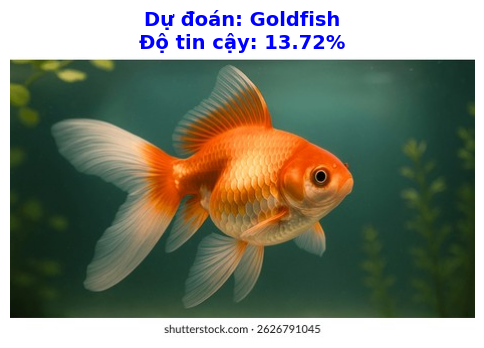

In [42]:
# --- KHU VỰC NHẬP ẢNH ---
# Bạn dán Link Online hoặc Đường dẫn file vào đây:
INPUT_IMAGE = "https://www.shutterstock.com/image-photo/highresolution-photo-beautiful-goldfish-swimming-260nw-2626791045.jpg"

# Ví dụ link online (bỏ comment để thử):
# INPUT_IMAGE = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3b/Royal_Bengal_Tiger_at_Kanha_National_Park.jpg/640px-Royal_Bengal_Tiger_at_Kanha_National_Park.jpg"

# --- CHẠY DỰ ĐOÁN ---
run_prediction(INPUT_IMAGE)